# 🖼️ polars-vision: Comprehensive Demo

This notebook provides a complete demonstration of the **polars-vision** plugin - a high-performance vision/array processing plugin for Polars DataFrames.

## What is polars-vision?

polars-vision enables:
- **Lazy, zero-copy image processing** on DataFrame columns
- **Composable pipelines** with automatic fused execution via DAG-based graphs
- **Multi-domain operations** - seamlessly move between images, masks, contours, and scalars
- **Multi-source & multi-output** - read from multiple columns, output multiple named results
- **Named nodes with aliases** - define reusable pipeline checkpoints
- **Common Subexpression Elimination (CSE)** - automatic optimization of shared operations
- **Dynamic parameters** using Polars expressions for per-row customization
- **Binary operations** between pipelines (add, subtract, multiply, blend, mask)
- **Seamless ML integration** with NumPy, PyTorch, and other frameworks

The plugin leverages **view-buffer**, a Rust crate providing stride-aware tensor operations with automatic kernel fusion.

---

## Table of Contents

1. [Setup & Imports](#1-setup--imports)
2. [Basic Pipeline Operations](#2-basic-pipeline-operations)
3. [DType Promotion & Normalization](#3-dtype-promotion--normalization)
4. [Dynamic Parameters with Expressions](#4-dynamic-parameters-with-expressions)
5. [Geometry Operations](#5-geometry-operations)
6. [Lazy Pipeline Composition](#6-lazy-pipeline-composition)
7. [Binary Operations & Mask Application](#7-binary-operations--mask-application)
8. [Multi-Source Pipelines](#8-multi-source-pipelines)
9. [Multi-Output with Named Nodes](#9-multi-output-with-named-nodes)
10. [Reusable & Composable Pipeline Patterns](#10-reusable--composable-pipeline-patterns)
11. [Domain Transitions: Images ↔ Contours ↔ Scalars](#11-domain-transitions-images--contours--scalars)
12. [ML Workflow: Segmentation Pipeline](#12-ml-workflow-segmentation-pipeline)
13. [PyTorch Integration](#13-pytorch-integration)
14. [Conclusion](#14-conclusion)

## 1. Setup & Imports

First, let's import the necessary packages and set up helper functions for displaying images.

In [47]:
# Set up non-interactive matplotlib backend for script execution
# This prevents plt.show() from blocking when running as a script
import os

if os.environ.get("MPLBACKEND") is None and not hasattr(os, "_called_from_jupyter"):
    import matplotlib

    matplotlib.use("Agg")

# Core imports
import io
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from PIL import Image

# polars-vision imports
from polars_vision import (
    BBOX_SCHEMA,
    CONTOUR_SCHEMA,
    POINT_SCHEMA,
    Pipeline,
    numpy_from_bytes,
)
from polars_vision.geometry.schemas import contour_from_points

# Display settings
plt.rcParams["figure.figsize"] = [12, 4]
plt.rcParams["figure.dpi"] = 100

print(f"✅ Polars version: {pl.__version__}")
print("✅ polars-vision loaded successfully")

✅ Polars version: 1.36.1
✅ polars-vision loaded successfully


In [48]:
# Helper functions for displaying images


def bytes_to_image(data: bytes) -> Image.Image:
    """Convert image bytes (PNG/JPEG) to PIL Image."""
    return Image.open(io.BytesIO(data))


# Note: numpy_from_bytes is imported from polars_vision
# It automatically parses the header with dtype and shape info from numpy sink output


def display_images(
    images: list[Any], titles: list[str] | None = None, cmap: str | None = None
) -> None:
    """Display multiple images side by side."""
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]

    for i, (ax, img) in enumerate(zip(axes, images)):
        if isinstance(img, bytes):
            img = bytes_to_image(img)
        ax.imshow(img, cmap=cmap)
        ax.axis("off")
        if titles:
            ax.set_title(titles[i])
    plt.tight_layout()
    plt.show()


def display_arrays(
    arrays: list[np.ndarray], titles: list[str] | None = None, cmap: str = "viridis"
) -> None:
    """Display multiple numpy arrays as heatmaps."""
    n = len(arrays)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]

    for i, (ax, arr) in enumerate(zip(axes, arrays)):
        im = ax.imshow(arr, cmap=cmap)
        ax.axis("off")
        if titles:
            ax.set_title(titles[i])
        plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.show()


print("✅ Helper functions defined")

✅ Helper functions defined


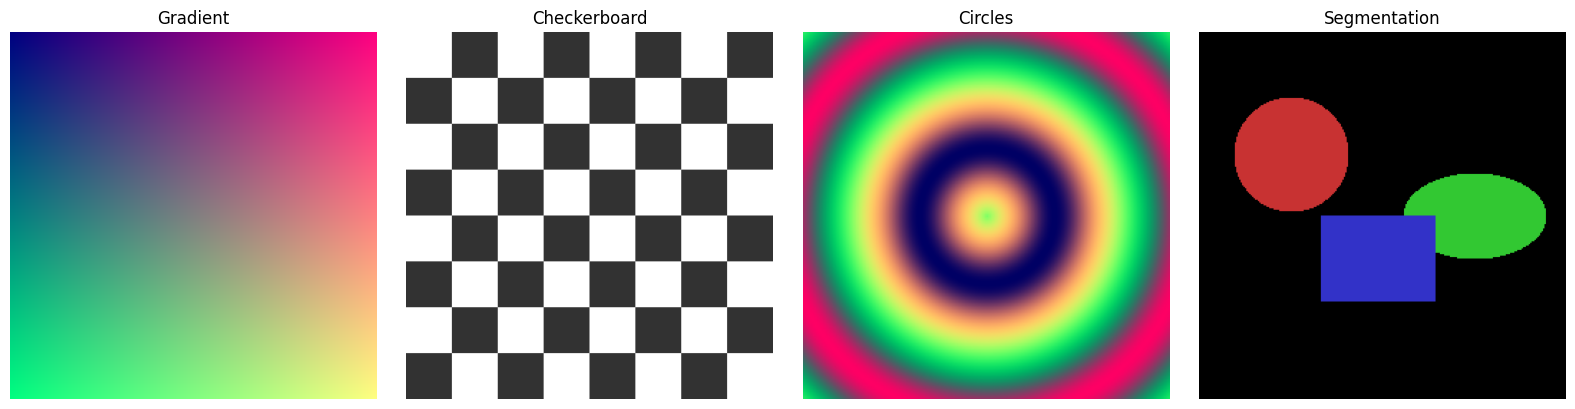

Created 6 test images


In [49]:
# Create sample test images for the demo


def create_test_image(
    width: int = 256, height: int = 256, pattern: str = "gradient"
) -> bytes:
    """Create a test image with various patterns."""
    if pattern == "gradient":
        # RGB gradient pattern
        r = np.linspace(0, 255, width, dtype=np.uint8)
        g = np.linspace(0, 255, height, dtype=np.uint8)
        img = np.zeros((height, width, 3), dtype=np.uint8)
        img[:, :, 0] = r[np.newaxis, :]  # Red gradient horizontal
        img[:, :, 1] = g[:, np.newaxis]  # Green gradient vertical
        img[:, :, 2] = 128  # Blue constant
    elif pattern == "checkerboard":
        block_size = 32
        img = np.zeros((height, width, 3), dtype=np.uint8)
        for i in range(0, height, block_size):
            for j in range(0, width, block_size):
                if ((i // block_size) + (j // block_size)) % 2 == 0:
                    img[i : i + block_size, j : j + block_size] = [255, 255, 255]
                else:
                    img[i : i + block_size, j : j + block_size] = [50, 50, 50]
    elif pattern == "circles":
        # Concentric circles
        y, x = np.ogrid[:height, :width]
        cx, cy = width // 2, height // 2
        r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
        img = np.zeros((height, width, 3), dtype=np.uint8)
        img[:, :, 0] = ((np.sin(r / 10) + 1) * 127.5).astype(np.uint8)
        img[:, :, 1] = ((np.cos(r / 15) + 1) * 127.5).astype(np.uint8)
        img[:, :, 2] = 100
    elif pattern == "heatmap":
        # Gaussian heatmap for ML demo
        y, x = np.ogrid[:height, :width]
        cx, cy = width // 2 + 30, height // 2 - 20
        sigma = 50
        gaussian = np.exp(-((x - cx) ** 2 + (y - cy) ** 2) / (2 * sigma**2))
        img = (gaussian * 255).astype(np.uint8)
        img = np.stack([img, img, img], axis=-1)  # Grayscale as RGB
    elif pattern == "segmentation":
        # Multi-region segmentation mask style
        img = np.zeros((height, width, 3), dtype=np.uint8)
        # Region 1: circle
        y, x = np.ogrid[:height, :width]
        cx1, cy1 = width // 4, height // 3
        r1 = np.sqrt((x - cx1) ** 2 + (y - cy1) ** 2)
        img[r1 < 40] = [200, 50, 50]  # Red
        # Region 2: ellipse
        cx2, cy2 = 3 * width // 4, height // 2
        ellipse = ((x - cx2) / 50) ** 2 + ((y - cy2) / 30) ** 2
        img[ellipse < 1] = [50, 200, 50]  # Green
        # Region 3: rectangle
        img[height // 2 : height // 2 + 60, width // 3 : width // 3 + 80] = [
            50,
            50,
            200,
        ]
    else:
        # Random noise
        rng = np.random.default_rng(42)
        img = rng.integers(0, 256, (height, width, 3), dtype=np.uint8)

    # Convert to PNG bytes
    pil_img = Image.fromarray(img)
    buffer = io.BytesIO()
    pil_img.save(buffer, format="PNG")
    return buffer.getvalue()


# Create test images
test_images = {
    "gradient": create_test_image(256, 256, "gradient"),
    "checkerboard": create_test_image(256, 256, "checkerboard"),
    "circles": create_test_image(256, 256, "circles"),
    "heatmap": create_test_image(256, 256, "heatmap"),
    "segmentation": create_test_image(256, 256, "segmentation"),
    "noise": create_test_image(256, 256, "noise"),
}

# Display them
display_images(
    [
        test_images["gradient"],
        test_images["checkerboard"],
        test_images["circles"],
        test_images["segmentation"],
    ],
    ["Gradient", "Checkerboard", "Circles", "Segmentation"],
)
print(f"Created {len(test_images)} test images")

## 2. Basic Pipeline Operations

polars-vision uses a fluent **Pipeline** API to define image processing operations. A complete pipeline has three parts:

1. **Source**: How to interpret input data (`image_bytes`, `blob`, `raw`, `file_path`, `contour`)
2. **Operations**: The transformations to apply (resize, grayscale, normalize, etc.)
3. **Sink**: The output format (`numpy`, `torch`, `png`, `jpeg`, `blob`, `native`)

### 2.1 Your First Pipeline

Pipeline specification:
Pipeline().source('image_bytes').resize(height=50, width=50, filter=lanczos3).sink('png')

Original DataFrame schema: Schema({'name': String, 'image': Binary})
Result DataFrame schema: Schema({'name': String, 'image': Binary, 'resized': Binary})


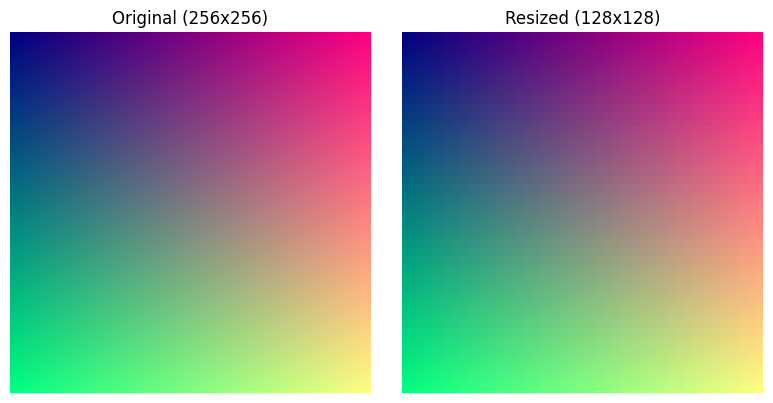

In [51]:
# Define a simple resize pipeline
resize_pipe = (
    Pipeline()
    .source("image_bytes")  # Input is PNG/JPEG bytes
    .resize(height=50, width=50)  # Resize to 128x128
    .sink("png")  # Output as PNG bytes
)

# Print the pipeline structure
print("Pipeline specification:")
print(resize_pipe)
print()

# Create a DataFrame with images
df = pl.DataFrame(
    {
        "name": ["gradient", "checkerboard", "circles"],
        "image": [
            test_images["gradient"],
            test_images["checkerboard"],
            test_images["circles"],
        ],
    }
)

# Apply the pipeline using .cv.pipeline()
result = df.with_columns(resized=pl.col("image").cv.pipeline(resize_pipe))

print(f"Original DataFrame schema: {df.schema}")
print(f"Result DataFrame schema: {result.schema}")

# Display original vs resized
row = result.row(0, named=True)
display_images(
    [row["image"], row["resized"]], ["Original (256x256)", "Resized (128x128)"]
)

### 2.2 Resize Filter Types

polars-vision supports three resize filter types:
- **nearest**: Fastest, best for pixel art or binary masks
- **bilinear**: Good balance of speed and quality
- **lanczos3**: Best quality, slower (default)

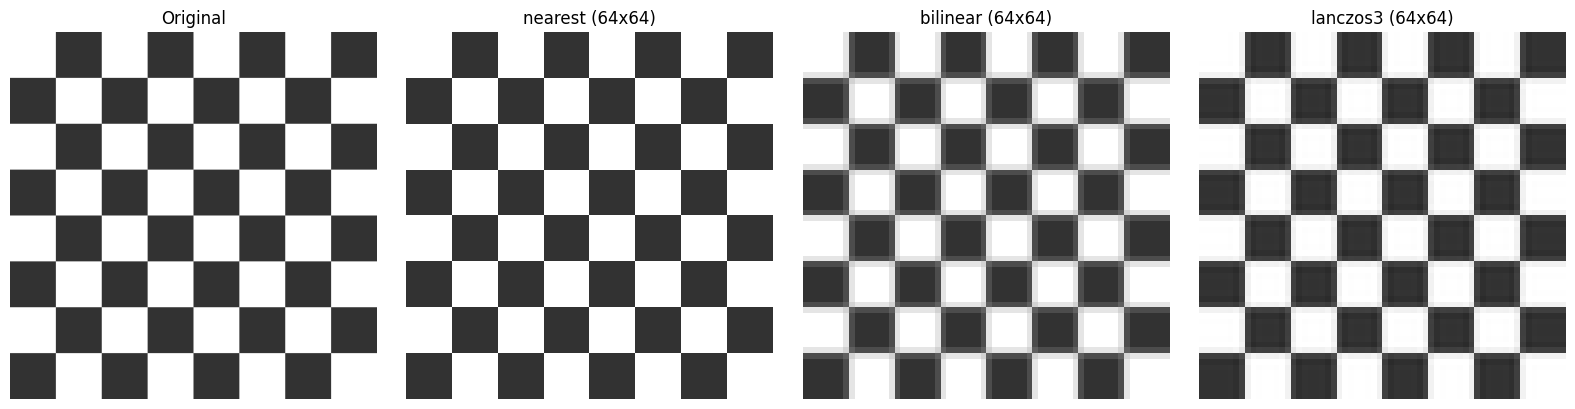

In [52]:
# Compare resize filters
filters = ["nearest", "bilinear", "lanczos3"]
resized_images = []

for filter_type in filters:
    pipe = (
        Pipeline()
        .source("image_bytes")
        .resize(height=64, width=64, filter=filter_type)
        .sink("png")
    )
    result = pl.DataFrame({"img": [test_images["checkerboard"]]}).with_columns(
        out=pl.col("img").cv.pipeline(pipe)
    )
    resized_images.append(result["out"][0])

display_images(
    [test_images["checkerboard"]] + resized_images,
    ["Original"] + [f"{f} (64x64)" for f in filters],
)

### 2.3 Common Image Operations

Let's explore common image operations with intermediate outputs:

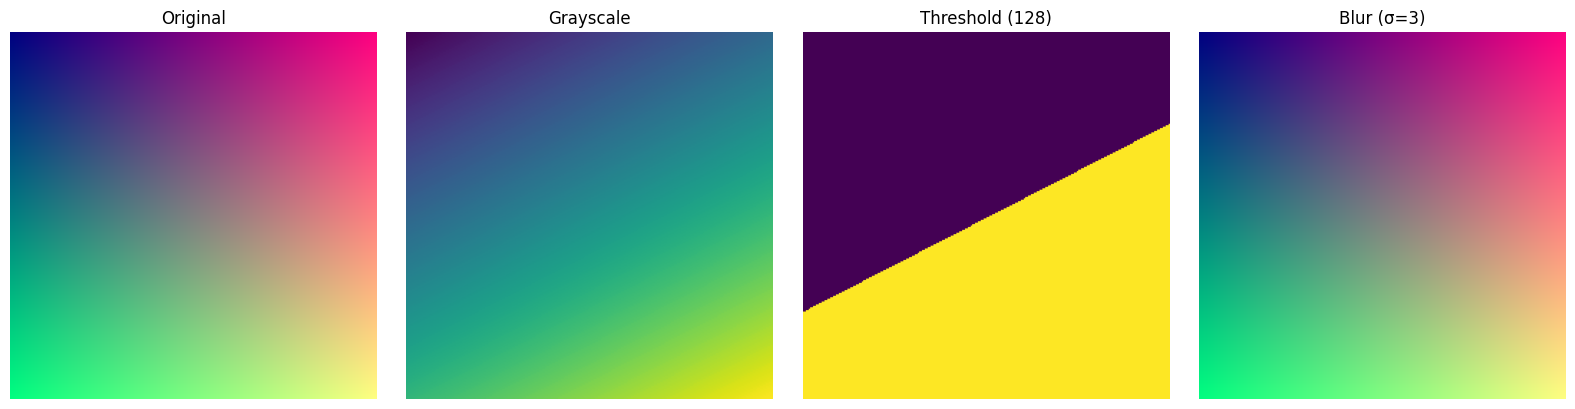

In [53]:
# Grayscale conversion
gray_pipe = Pipeline().source("image_bytes").grayscale().sink("png")

# Threshold (binary)
threshold_pipe = Pipeline().source("image_bytes").grayscale().threshold(128).sink("png")

# Blur
blur_pipe = Pipeline().source("image_bytes").blur(sigma=3.0).sink("png")

# Apply all to gradient image
test_df = pl.DataFrame({"img": [test_images["gradient"]]})
ops_result = test_df.with_columns(
    gray=pl.col("img").cv.pipeline(gray_pipe),
    threshold=pl.col("img").cv.pipeline(threshold_pipe),
    blur=pl.col("img").cv.pipeline(blur_pipe),
)

row = ops_result.row(0, named=True)
display_images(
    [row["img"], row["gray"], row["threshold"], row["blur"]],
    ["Original", "Grayscale", "Threshold (128)", "Blur (σ=3)"],
)

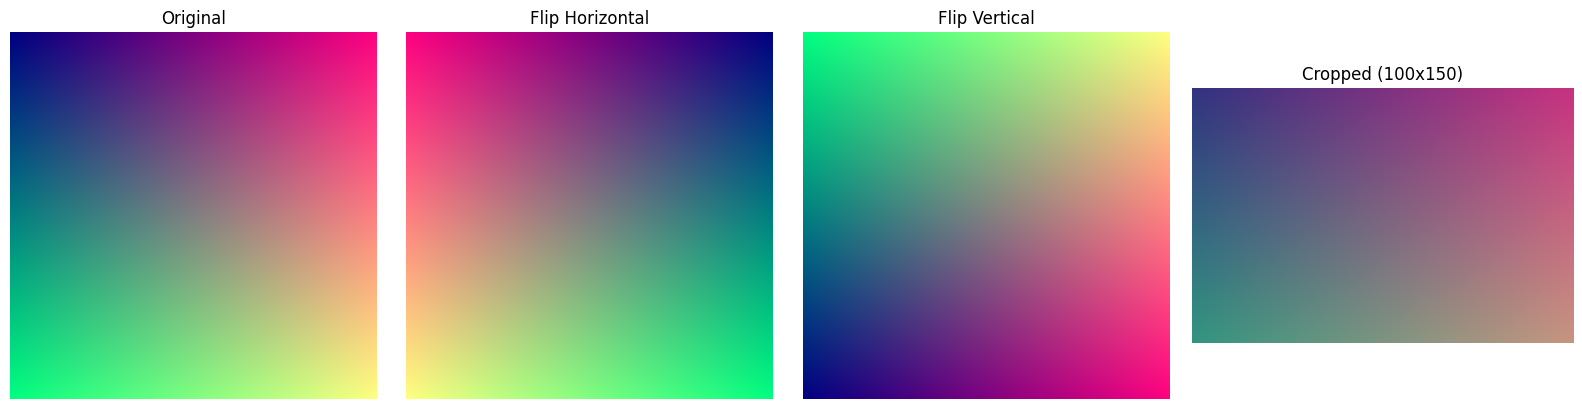

In [54]:
# Flip operations and cropping
flip_h_pipe = Pipeline().source("image_bytes").flip_h().sink("png")
flip_v_pipe = Pipeline().source("image_bytes").flip_v().sink("png")
crop_pipe = (
    Pipeline()
    .source("image_bytes")
    .crop(top=50, left=50, height=100, width=150)
    .sink("png")
)

test_df = pl.DataFrame({"img": [test_images["gradient"]]})
flip_result = test_df.with_columns(
    flip_h=pl.col("img").cv.pipeline(flip_h_pipe),
    flip_v=pl.col("img").cv.pipeline(flip_v_pipe),
    crop=pl.col("img").cv.pipeline(crop_pipe),
)

row = flip_result.row(0, named=True)
display_images(
    [row["img"], row["flip_h"], row["flip_v"], row["crop"]],
    ["Original", "Flip Horizontal", "Flip Vertical", "Cropped (100x150)"],
)

### 2.4 Chained Operations

Pipeline operations can be chained together. The operations are executed in a single pass through the Rust backend:

ML Preprocessing Pipeline:
Pipeline().source('image_bytes').resize(height=256, width=256, filter=lanczos3).crop(top=16, left=16, height=224, width=224).flip(axes=[1]).sink('png')


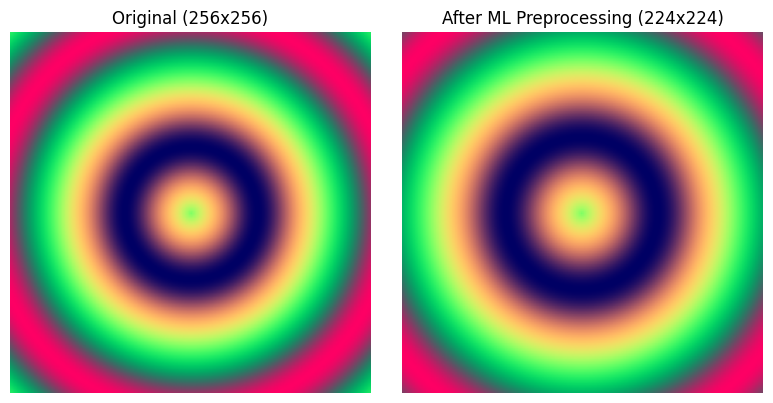

In [55]:
# Complex chained pipeline - common preprocessing for ML
ml_preprocess_pipe = (
    Pipeline()
    .source("image_bytes")
    .resize(height=256, width=256)  # Resize to standard size
    .crop(top=16, left=16, height=224, width=224)  # Center crop
    .flip_h()  # Data augmentation
    .sink("png")
)

print("ML Preprocessing Pipeline:")
print(ml_preprocess_pipe)

# Apply to test image
result = pl.DataFrame({"img": [test_images["circles"]]}).with_columns(
    processed=pl.col("img").cv.pipeline(ml_preprocess_pipe)
)

row = result.row(0, named=True)
display_images(
    [row["img"], row["processed"]],
    ["Original (256x256)", "After ML Preprocessing (224x224)"],
)

## 3. DType Promotion & Normalization

polars-vision implements an automatic **DType Promotion System** that handles type conversions seamlessly. Operations like `normalize` accept any numeric input and automatically promote integers to floats.

### Key Concepts:
- **MinMax normalization**: Scales values to [0, 1] range
- **ZScore normalization**: Centers data around 0 with unit standard deviation
- Outputs are float32 by default (configurable with `out_dtype`)

MinMax range: [0.000, 1.000]
ZScore mean: -0.000, std: 1.000


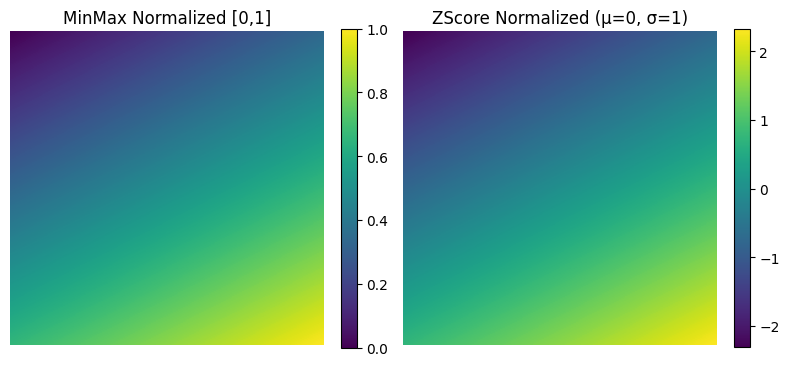

In [58]:
# Normalization pipelines
# Note: When using 'numpy' sink, we get raw bytes that can be converted back to arrays

# MinMax normalization - outputs float32 in [0, 1]
minmax_pipe = (
    Pipeline()
    .source("image_bytes")
    .grayscale()  # Convert to single channel for easier visualization
    .normalize(method="minmax")
    .sink("numpy")
)

# ZScore normalization - outputs float32 with mean=0, std=1
zscore_pipe = (
    Pipeline()
    .source("image_bytes")
    .grayscale()
    .normalize(method="zscore")
    .sink("numpy")
)

# Apply both
result = pl.DataFrame({"img": [test_images["gradient"]]}).with_columns(
    minmax=pl.col("img").cv.pipeline(minmax_pipe),
    zscore=pl.col("img").cv.pipeline(zscore_pipe),
)

# Convert back to arrays for visualization using numpy_from_bytes
# It automatically parses the header with shape/dtype info
minmax_arr = numpy_from_bytes(result["minmax"][0])
zscore_arr = numpy_from_bytes(result["zscore"][0])

print(f"MinMax range: [{minmax_arr.min():.3f}, {minmax_arr.max():.3f}]")
print(f"ZScore mean: {zscore_arr.mean():.3f}, std: {zscore_arr.std():.3f}")

display_arrays(
    [minmax_arr.squeeze(), zscore_arr.squeeze()],
    ["MinMax Normalized [0,1]", "ZScore Normalized (μ=0, σ=1)"],
)

Scaled range: [7.5, 120.5]
Clamped range: [0.20, 0.80]


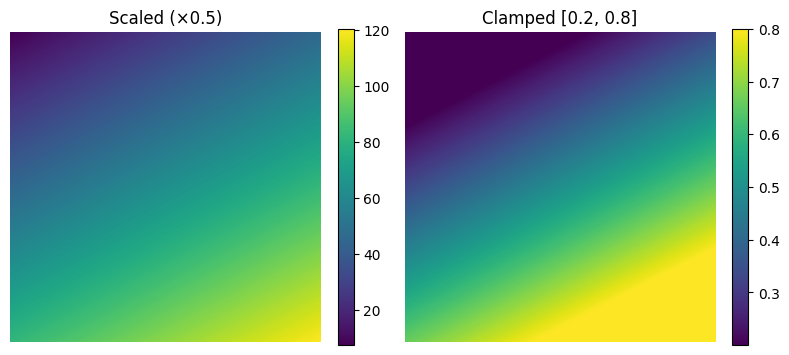

In [59]:
# Scale and clamp operations
# These also support automatic dtype promotion

# Scale by factor
scale_pipe = (
    Pipeline()
    .source("image_bytes")
    .grayscale()
    .scale(factor=0.5)  # Halve all values
    .sink("numpy")
)

# Clamp to range
clamp_pipe = (
    Pipeline()
    .source("image_bytes")
    .grayscale()
    .normalize(method="minmax")  # [0, 1]
    .clamp(min_val=0.2, max_val=0.8)  # Clip to [0.2, 0.8]
    .sink("numpy")
)

result = pl.DataFrame({"img": [test_images["gradient"]]}).with_columns(
    scaled=pl.col("img").cv.pipeline(scale_pipe),
    clamped=pl.col("img").cv.pipeline(clamp_pipe),
)

# scale output is f32 (promoted from u8), clamp is also f32
scaled_arr = numpy_from_bytes(result["scaled"][0])
clamped_arr = numpy_from_bytes(result["clamped"][0])

print(f"Scaled range: [{scaled_arr.min():.1f}, {scaled_arr.max():.1f}]")
print(f"Clamped range: [{clamped_arr.min():.2f}, {clamped_arr.max():.2f}]")

display_arrays(
    [scaled_arr.squeeze(), clamped_arr.squeeze()],
    ["Scaled (×0.5)", "Clamped [0.2, 0.8]"],
)

## 4. Dynamic Parameters with Expressions

One of polars-vision's most powerful features is **dynamic parameters**. Any pipeline parameter can be a Polars expression (`pl.col(...)`) that gets resolved per-row at execution time.

This enables:
- Per-image resize dimensions based on metadata
- Adaptive thresholding based on image statistics
- Dynamic cropping based on detected regions

Each image resized to different dimensions:
shape: (3, 4)
┌────────┬──────────┬──────────┬──────────────┐
│ name   ┆ target_h ┆ target_w ┆ output_bytes │
│ ---    ┆ ---      ┆ ---      ┆ ---          │
│ str    ┆ i64      ┆ i64      ┆ u32          │
╞════════╪══════════╪══════════╪══════════════╡
│ small  ┆ 64       ┆ 64       ┆ 7927         │
│ medium ┆ 128      ┆ 128      ┆ 25042        │
│ large  ┆ 200      ┆ 200      ┆ 52852        │
└────────┴──────────┴──────────┴──────────────┘


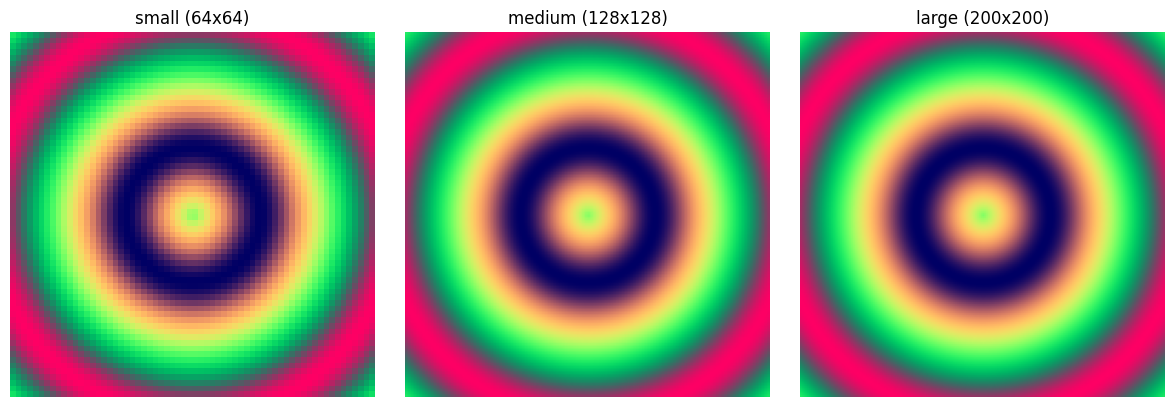

In [61]:
# Dynamic resize - each row gets different dimensions!
dynamic_resize_pipe = (
    Pipeline()
    .source("image_bytes")
    .resize(
        height=pl.col("target_h"), width=pl.col("target_w")
    )  # Expression parameters!
    .sink("png")
)

# Create DataFrame with per-row dimensions
df = pl.DataFrame(
    {
        "name": ["small", "medium", "large"],
        "image": [test_images["circles"]] * 3,
        "target_h": [64, 128, 200],
        "target_w": [64, 128, 200],
    }
)

result = df.with_columns(resized=pl.col("image").cv.pipeline(dynamic_resize_pipe))

print("Each image resized to different dimensions:")
print(
    result.select(
        "name",
        "target_h",
        "target_w",
        pl.col("resized").bin.size().alias("output_bytes"),
    )
)

# Display all resized images
display_images(
    [result["resized"][i] for i in range(3)],
    [
        f"{row['name']} ({row['target_h']}x{row['target_w']})"
        for row in result.iter_rows(named=True)
    ],
)

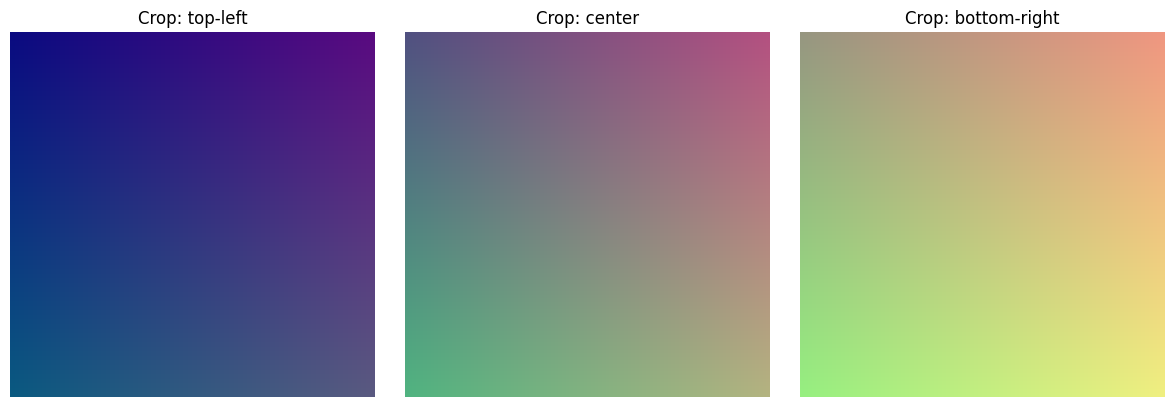

In [62]:
# Dynamic crop based on bounding box columns
dynamic_crop_pipe = (
    Pipeline()
    .source("image_bytes")
    .crop(
        top=pl.col("bbox_y"),
        left=pl.col("bbox_x"),
        height=pl.col("bbox_h"),
        width=pl.col("bbox_w"),
    )
    .sink("png")
)

# Simulate detected bounding boxes
df = pl.DataFrame(
    {
        "image": [test_images["gradient"]] * 3,
        "region": ["top-left", "center", "bottom-right"],
        "bbox_x": [10, 80, 150],
        "bbox_y": [10, 80, 150],
        "bbox_w": [80, 100, 90],
        "bbox_h": [80, 100, 90],
    }
)

result = df.with_columns(cropped=pl.col("image").cv.pipeline(dynamic_crop_pipe))

display_images(
    [result["cropped"][i] for i in range(3)],
    [f"Crop: {row['region']}" for row in result.iter_rows(named=True)],
)

## 5. Geometry Operations

polars-vision provides a comprehensive geometry module for working with **contours**, **points**, and **bounding boxes**. This is essential for computer vision tasks like:
- Object detection and segmentation
- Annotation processing
- IoU/Dice metrics calculation

### 5.1 Contour Schema

Contours are stored as Polars Struct columns with the following schema:

In [63]:
# Show the contour schema
print("CONTOUR_SCHEMA:")
print(CONTOUR_SCHEMA)
print()
print("POINT_SCHEMA:")
print(POINT_SCHEMA)
print()
print("BBOX_SCHEMA:")
print(BBOX_SCHEMA)

CONTOUR_SCHEMA:
Struct({'exterior': List(Struct({'x': Float64, 'y': Float64})), 'holes': List(List(Struct({'x': Float64, 'y': Float64}))), 'is_closed': Boolean})

POINT_SCHEMA:
Struct({'x': Float64, 'y': Float64})

BBOX_SCHEMA:
Struct({'x': Float64, 'y': Float64, 'width': Float64, 'height': Float64})


In [64]:
# Create contours using the helper function
contours = [
    # Square contour
    contour_from_points([(50, 50), (50, 150), (150, 150), (150, 50)]),
    # Triangle contour
    contour_from_points([(100, 30), (30, 170), (170, 170)]),
    # Irregular polygon (L-shape)
    contour_from_points(
        [(20, 20), (20, 180), (100, 180), (100, 100), (180, 100), (180, 20)]
    ),
]

# Create DataFrame with contours
contour_df = pl.DataFrame(
    {
        "name": ["square", "triangle", "L-shape"],
        "contour": contours,
    }
).cast({"contour": CONTOUR_SCHEMA})

print("Contour DataFrame:")
print(contour_df)

Contour DataFrame:
shape: (3, 2)
┌──────────┬─────────────────────────────────┐
│ name     ┆ contour                         │
│ ---      ┆ ---                             │
│ str      ┆ struct[3]                       │
╞══════════╪═════════════════════════════════╡
│ square   ┆ {[{50.0,50.0}, {50.0,150.0}, …… │
│ triangle ┆ {[{100.0,30.0}, {30.0,170.0}, … │
│ L-shape  ┆ {[{20.0,20.0}, {20.0,180.0}, …… │
└──────────┴─────────────────────────────────┘


### 5.2 Geometric Measures

The `.contour` namespace provides operations for computing geometric properties.

In [65]:
# Compute geometric measures using the .contour namespace
measures_df = contour_df.with_columns(
    area=pl.col("contour").contour.area(),
    perimeter=pl.col("contour").contour.perimeter(),
    winding=pl.col("contour").contour.winding(),
    is_convex=pl.col("contour").contour.is_convex(),
)

print("Geometric Measures:")
print(measures_df.select("name", "area", "perimeter", "winding", "is_convex"))

Geometric Measures:
shape: (3, 5)
┌──────────┬─────────┬────────────┬─────────┬───────────┐
│ name     ┆ area    ┆ perimeter  ┆ winding ┆ is_convex │
│ ---      ┆ ---     ┆ ---        ┆ ---     ┆ ---       │
│ str      ┆ f64     ┆ f64        ┆ str     ┆ bool      │
╞══════════╪═════════╪════════════╪═════════╪═══════════╡
│ square   ┆ 10000.0 ┆ 400.0      ┆ cw      ┆ true      │
│ triangle ┆ 9800.0  ┆ 453.049517 ┆ cw      ┆ true      │
│ L-shape  ┆ 19200.0 ┆ 640.0      ┆ cw      ┆ false     │
└──────────┴─────────┴────────────┴─────────┴───────────┘


### 5.3 Rasterizing Contours to Masks

The `source("contour")` operation rasterizes contours to binary masks.
You specify the output dimensions with width/height parameters.

Contour rasterization with Pipeline().source('contour'):
shape: (3, 2)
┌──────────┬─────────────────────────────────┐
│ name     ┆ mask                            │
│ ---      ┆ ---                             │
│ str      ┆ binary                          │
╞══════════╪═════════════════════════════════╡
│ square   ┆ b"\x00\x03\xc8\x00\x00\x00\x00… │
│ triangle ┆ b"\x00\x03\xc8\x00\x00\x00\x00… │
│ L-shape  ┆ b"\x00\x03\xc8\x00\x00\x00\x00… │
└──────────┴─────────────────────────────────┘
✅ Rasterized mask shape: (200, 200), dtype: uint8


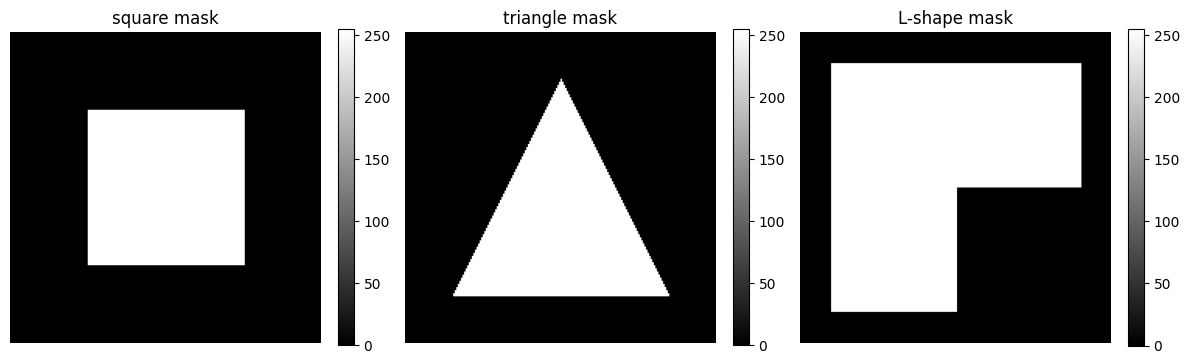

In [66]:
# Rasterize contours to masks using polars-vision pipeline
print("Contour rasterization with Pipeline().source('contour'):")

# Create a pipeline that rasterizes contour to a 200x200 mask
contour_pipe = Pipeline().source("contour", width=200, height=200).sink("numpy")

# Apply to contour DataFrame
contour_raster_result = contour_df.with_columns(
    mask=pl.col("contour").cv.pipeline(contour_pipe)
)
print(contour_raster_result.select("name", "mask"))

# Verify the mask shape and visualize
masks = []
for i in range(len(contour_raster_result)):
    mask_bytes = contour_raster_result["mask"][i]
    mask_arr = numpy_from_bytes(mask_bytes)
    masks.append(mask_arr.squeeze())

print(f"✅ Rasterized mask shape: {masks[0].shape}, dtype: {masks[0].dtype}")

display_arrays(
    masks,
    [f"{name} mask" for name in contour_raster_result["name"].to_list()],
    cmap="gray",
)

## 6. Lazy Pipeline Composition

polars-vision supports **lazy pipeline composition** using `LazyPipelineExpr`. This enables:

1. **Fused execution**: Multiple pipelines combined into a single plugin call
2. **Named checkpoints**: Mark intermediate points with `.alias()`
3. **Pipeline chaining**: Use `.pipe()` to chain operations
4. **Binary operations**: Add, subtract, multiply, divide, blend arrays
5. **Mask application**: Apply masks from contours or other images

### Two Modes:
- **Eager mode**: `pl.col("x").cv.pipeline(pipe)` - Returns `pl.Expr` directly (requires sink in pipeline)
- **Lazy mode**: `pl.col("x").cv.pipe(pipe)` - Returns `LazyPipelineExpr` for composition (sink at the end)

In [67]:
# Lazy mode example - compose pipelines before execution

# Define pipelines WITHOUT sinks (for lazy composition)
img_pipe = Pipeline().source("image_bytes").resize(height=200, width=200)

# Create lazy expressions using .cv.pipe()
img_expr = pl.col("image").cv.pipe(img_pipe)  # Returns LazyPipelineExpr

print(f"img_expr type: {type(img_expr)}")
print(f"img_expr: {img_expr}")
print()
print("These are NOT Polars expressions yet - they need .sink() to materialize!")

img_expr type: <class 'polars_vision.lazy.LazyPipelineExpr'>
img_expr: LazyPipelineExpr(node='node_9107784b', upstream=[]) - call .sink(format) to execute

These are NOT Polars expressions yet - they need .sink() to materialize!


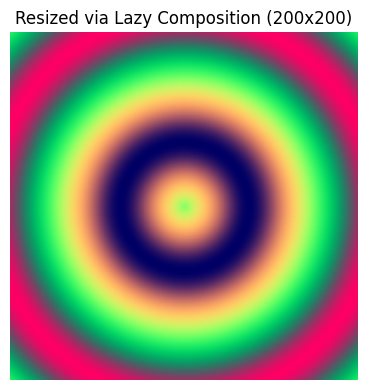

In [69]:
# Execute the lazy pipeline with .sink()

# Create test data
compose_df = pl.DataFrame({"image": [test_images["circles"]]})

# Method 1: Simple lazy composition
result = compose_df.with_columns(
    resized=pl.col("image").cv.pipe(img_pipe).sink("png"),
)

display_images([result["resized"][0]], ["Resized via Lazy Composition (200x200)"])

### 6.1 Pipeline Chaining with `.pipe()`

The `.pipe()` method allows chaining additional operations onto an existing `LazyPipelineExpr`.
When the chained pipeline has **no source**, it continues from the upstream node's output.

Chained LazyPipelineExpr:
  base: LazyPipelineExpr(node='node_d54b39f5', upstream=[]) - call .sink(format) to execute
  gray: LazyPipelineExpr(node='node_d346e0ed', upstream=['node_d54b39f5']) - call .sink(format) to execute
  thresh: LazyPipelineExpr(node='node_d670de41', upstream=['node_d346e0ed']) - call .sink(format) to execute


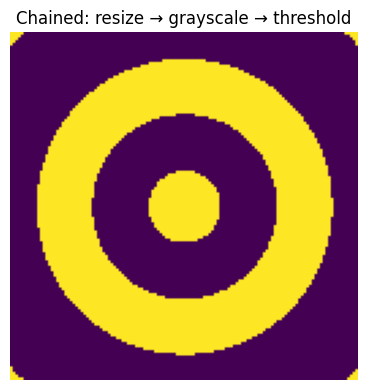

In [71]:
# Define base processing and chain additional operations
base_pipe = Pipeline().source("image_bytes").resize(height=128, width=128)
gray_ops = Pipeline().grayscale()  # No source - will continue from upstream
thresh_ops = Pipeline().threshold(128)  # No source - chains further

# Chain operations using .pipe()
base = pl.col("image").cv.pipe(base_pipe)
gray = base.pipe(gray_ops)  # Continues from 'base'
thresh = gray.pipe(thresh_ops)  # Continues from 'gray'

print("Chained LazyPipelineExpr:")
print(f"  base: {base}")
print(f"  gray: {gray}")
print(f"  thresh: {thresh}")

# Execute the final result
result = compose_df.with_columns(binary=thresh.sink("png"))
display_images([result["binary"][0]], ["Chained: resize → grayscale → threshold"])

## 7. Binary Operations & Mask Application

polars-vision supports element-wise binary operations between two `LazyPipelineExpr` instances.
These operations use **type-based semantics**:

| Operation | u8/u16 Behavior | f32/f64 Behavior |
|-----------|-----------------|------------------|
| `add` | Saturating (clamps to 255) | Standard |
| `subtract` | Saturating (clamps to 0) | Standard |
| `multiply` | Saturating | Standard |
| `blend` | Normalized: (a/255)*(b/255)*255 | Standard |
| `divide` | Integer division | Standard |
| `ratio` | Scaled: (a/b)*255 | Standard |

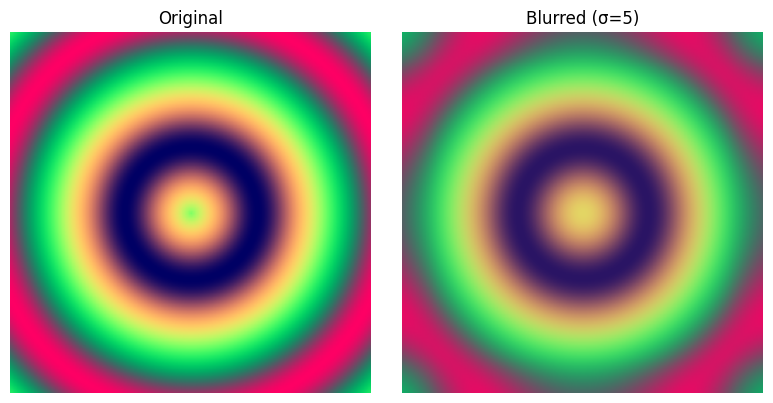

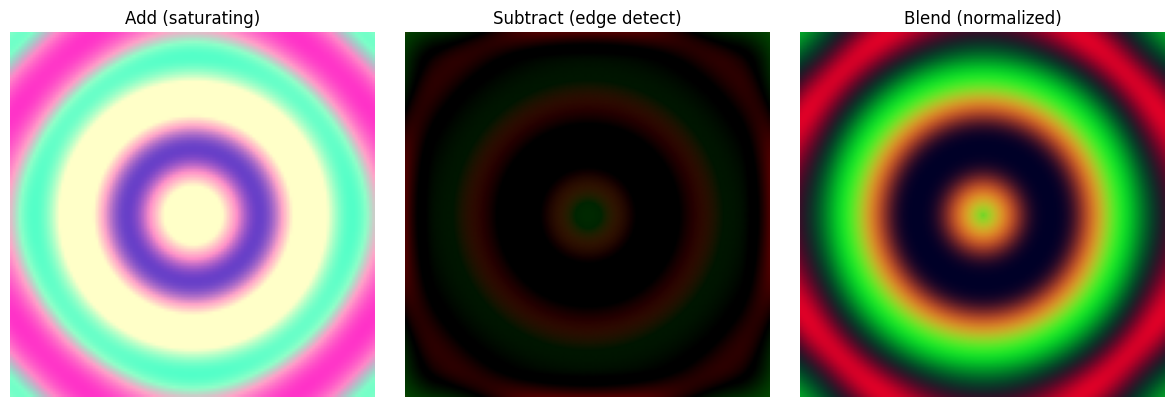

In [78]:
# Binary operations work between two pipelines with the same output shape
# We'll process the same image with different operations to demonstrate

df_binary = pl.DataFrame(
    {
        "image": [test_images["circles"]],
    }
)

# Define two pipelines that process the same image differently
# Both output 128x128 RGB images
pipe_original = Pipeline().source("image_bytes").resize(height=128, width=128)
pipe_blurred = (
    Pipeline().source("image_bytes").resize(height=128, width=128).blur(sigma=10.0)
)

# Create lazy expressions from the same source
img_original = pl.col("image").cv.pipe(pipe_original)
img_blurred = pl.col("image").cv.pipe(pipe_blurred)

# Binary operations (demonstrating with same-shape outputs)
add_result = img_original.add(img_blurred).sink("png")
subtract_result = img_original.subtract(img_blurred).sink("png")
blend_result = img_original.blend(img_blurred).sink("png")

result = df_binary.with_columns(
    original=img_original.sink("png"),
    blurred=img_blurred.sink("png"),
    added=add_result,
    subtracted=subtract_result,
    blended=blend_result,
)

row = result.row(0, named=True)
display_images(
    [row["original"], row["blurred"]],
    ["Original", "Blurred (σ=5)"],
)
display_images(
    [row["added"], row["subtracted"], row["blended"]],
    ["Add (saturating)", "Subtract (edge detect)", "Blend (normalized)"],
)

### 7.1 Mask Application

The `apply_mask()` method applies a binary mask to an image. Where the mask is zero,
the output is zero; where the mask is non-zero, the original values are preserved.

In [ ]:
# Create a circular mask using a contour
circle_contour = contour_from_points(
    [
        (64 + 50 * np.cos(a), 64 + 50 * np.sin(a))
        for a in np.linspace(0, 2 * np.pi, 32, endpoint=False)
    ]
)

df_mask = pl.DataFrame(
    {
        "image": [test_images["gradient"]],
        "mask_contour": [circle_contour],
    }
).cast({"mask_contour": CONTOUR_SCHEMA})

# Image pipeline
img_pipe = Pipeline().source("image_bytes").resize(height=128, width=128)
img = pl.col("image").cv.pipe(img_pipe)

# Contour source with explicit dimensions (rasterizes to mask)
mask_pipe = Pipeline().source("contour", width=128, height=128)
mask = pl.col("mask_contour").cv.pipe(mask_pipe)

# Apply mask to image
masked_result = img.apply_mask(mask).sink("png")

result = df_mask.with_columns(masked=masked_result)

row = result.row(0, named=True)
display_images(
    [row["image"], row["masked"]],
    ["Original", "Masked with Circular Contour"],
)

### 7.2 Shape Inference for Contour Sources

When working with composed pipelines, you can use `shape=` to infer contour rasterization
dimensions from another `LazyPipelineExpr`. This ensures the mask matches the image size.

In [ ]:
# Shape inference example - mask dimensions match image automatically
df_shape = pl.DataFrame(
    {
        "image": [test_images["circles"]],
        "contour": [
            contour_from_points([(30, 30), (30, 90), (90, 90), (90, 30)])
        ],  # Square
    }
).cast({"contour": CONTOUR_SCHEMA})

# Define image pipeline with specific dimensions
img_pipe = Pipeline().source("image_bytes").resize(height=100, width=150)  # Non-square!
img = pl.col("image").cv.pipe(img_pipe)

# Contour source with shape= to infer dimensions from image
mask_pipe = Pipeline().source("contour", shape=img)  # Auto-infers 150x100
mask = pl.col("contour").cv.pipe(mask_pipe)

# Apply mask
result = df_shape.with_columns(
    masked=img.apply_mask(mask).sink("png"),
)

print("Shape inference: contour mask auto-matched to 150x100 image")
display_images([result["masked"][0]], ["Masked with Auto-Sized Contour"])

### 7.3 Convenience: `apply_contour_mask()`

For the common case of applying a contour as a mask, use the convenience method
`apply_contour_mask()` which auto-infers dimensions from the image.

In [ ]:
# apply_contour_mask() convenience method
result = df_shape.with_columns(
    # This auto-infers dimensions from img's output shape
    masked=img.apply_contour_mask(mask).sink("png"),
)

display_images([result["masked"][0]], ["apply_contour_mask() convenience"])

## 8. Multi-Source Pipelines

polars-vision supports **multi-source** pipelines where different branches read from
different DataFrame columns. This is essential for workflows like:
- Comparing two images
- Applying a separately-loaded mask
- Computing difference between prediction and ground truth

In [ ]:
# Multi-source example: combine data from two different columns
# This demonstrates how to read from different DataFrame columns in one pipeline

df_multi = pl.DataFrame(
    {
        "base_image": [test_images["gradient"]],
        "overlay_image": [
            test_images["gradient"]
        ],  # Use same source for compatible shapes
    }
)

# Two separate pipelines reading from different columns
# Note: Both must produce same-shape outputs for binary operations
base_pipe = Pipeline().source("image_bytes").resize(height=128, width=128)
overlay_pipe = Pipeline().source("image_bytes").resize(height=128, width=128).flip_h()

# Create lazy expressions from different columns
base = pl.col("base_image").cv.pipe(base_pipe)
overlay = pl.col("overlay_image").cv.pipe(overlay_pipe)

# Blend them together - multi-source composition!
result = df_multi.with_columns(
    base_out=base.sink("png"),
    overlay_out=overlay.sink("png"),
    blended=base.blend(overlay).sink("png"),
)

row = result.row(0, named=True)
display_images(
    [row["base_out"], row["overlay_out"], row["blended"]],
    ["Base (gradient)", "Overlay (flipped)", "Blended"],
)

## 9. Multi-Output with Named Nodes

polars-vision supports **multi-output pipelines** using `.alias()` and dict-based `.sink()`.
This allows you to:

1. Mark intermediate points with `.alias(name)` - creates a named checkpoint
2. Return multiple outputs as a Struct column with `.sink({alias: format, ...})`
3. Use `.merge_pipe()` to combine branching pipelines for multi-output

### Benefits:
- Shared operations are computed once (not duplicated)
- Single plugin call for all outputs
- Automatic CSE optimization

In [ ]:
# Multi-output pipeline with aliases
df_multi_out = pl.DataFrame({"image": [test_images["circles"]]})

# Build a branching pipeline with named checkpoints
base = (
    pl.col("image")
    .cv.pipe(Pipeline().source("image_bytes").resize(height=128, width=128))
    .alias("resized")  # Checkpoint 1
)

# Branch 1: grayscale
gray = base.pipe(Pipeline().grayscale()).alias("gray")  # Checkpoint 2

# Branch 2: threshold (from grayscale)
thresh = gray.pipe(Pipeline().threshold(128)).alias("thresh")  # Checkpoint 3

# Branch 3: blur (from grayscale)
blur = gray.pipe(Pipeline().blur(sigma=3.0)).alias("blur")  # Checkpoint 4

# Merge branches and sink multiple outputs
merged = thresh.merge_pipe(blur)  # Combine branches for multi-output

# Sink with dict: returns Struct column with named Binary fields
result = df_multi_out.with_columns(
    outputs=merged.sink(
        {
            "resized": "png",
            "gray": "png",
            "thresh": "png",
            "blur": "png",
        }
    )
)

print("Multi-output result schema:", result.schema)
print()
print("Outputs column contains a Struct with named fields:")
print(result["outputs"].dtype)

In [ ]:
# Extract individual outputs from the Struct column
extracted = result.select(
    pl.col("outputs").struct.field("resized").alias("resized_png"),
    pl.col("outputs").struct.field("gray").alias("gray_png"),
    pl.col("outputs").struct.field("thresh").alias("thresh_png"),
    pl.col("outputs").struct.field("blur").alias("blur_png"),
)

# Display all outputs
display_images(
    [
        extracted["resized_png"][0],
        extracted["gray_png"][0],
        extracted["thresh_png"][0],
        extracted["blur_png"][0],
    ],
    ["Resized", "Grayscale", "Threshold", "Blur"],
)

print("✅ All 4 outputs computed from a single fused pipeline execution!")

### 9.1 Common Subexpression Elimination (CSE)

When multiple branches share common operations, polars-vision automatically detects
and extracts shared prefixes. This optimization is transparent - you don't need to
change your code!

**Example:**
```
Before CSE:
  gray_pipe: source → resize → grayscale
  mask_pipe: source → resize → grayscale → threshold → extract

After CSE:
  _shared:   source → resize → grayscale  (computed once)
  gray_pipe: (empty) ← upstream: _shared
  mask_pipe: threshold → extract ← upstream: _shared
```

In [ ]:
# CSE example: two branches with shared prefix
print("CSE Optimization Example:")
print()
print(
    "When we define two pipelines that both start with resize→grayscale,"
    " CSE automatically shares that prefix."
)
print()

# Both branches share: resize → grayscale
base = pl.col("image").cv.pipe(
    Pipeline().source("image_bytes").resize(height=100, width=100)
)
gray = base.pipe(Pipeline().grayscale()).alias("gray")

# Branch 1: blur
branch1 = gray.pipe(Pipeline().blur(2.0)).alias("blurred")

# Branch 2: threshold
branch2 = gray.pipe(Pipeline().threshold(128)).alias("thresholded")

# Merge and execute - CSE will share the gray computation
merged = branch1.merge_pipe(branch2)
result = df_multi_out.with_columns(
    outputs=merged.sink({"gray": "png", "blurred": "png", "thresholded": "png"})
)

extracted = result.select(
    pl.col("outputs").struct.field("gray").alias("gray"),
    pl.col("outputs").struct.field("blurred").alias("blurred"),
    pl.col("outputs").struct.field("thresholded").alias("thresholded"),
)

display_images(
    [extracted["gray"][0], extracted["blurred"][0], extracted["thresholded"][0]],
    ["Gray (shared)", "Branch 1: Blur", "Branch 2: Threshold"],
)

print("✅ Grayscale computed once and shared between both branches!")

## 10. Reusable & Composable Pipeline Patterns

The lazy composition system enables powerful **reusable pipeline patterns**:

1. **Define once, use many times** - Create pipeline fragments as variables
2. **Parameterized pipelines** - Functions that return configured pipelines
3. **Pipeline factories** - Create pipelines based on configuration

In [ ]:
# Pattern 1: Reusable pipeline fragments
preprocessing_ops = Pipeline().resize(height=128, width=128).flip_h()
augmentation_ops = Pipeline().blur(sigma=1.5)
normalization_ops = Pipeline().grayscale().normalize(method="minmax")


# Pattern 2: Parameterized pipeline factory
def create_resize_pipeline(size: int) -> Pipeline:
    """Create a resize pipeline with specified size."""
    return Pipeline().source("image_bytes").resize(height=size, width=size)


def create_augmentation_chain(flip: bool = True, blur_sigma: float = 0.0) -> Pipeline:
    """Create an augmentation pipeline with configurable options."""
    ops = Pipeline()
    if flip:
        ops = ops.flip_h()
    if blur_sigma > 0:
        ops = ops.blur(sigma=blur_sigma)
    return ops


# Use the factories
df_reuse = pl.DataFrame({"image": [test_images["gradient"]]})

# Compose reusable fragments
base = pl.col("image").cv.pipe(create_resize_pipeline(100))
augmented = base.pipe(create_augmentation_chain(flip=True, blur_sigma=2.0))
final = augmented.pipe(normalization_ops)

result = df_reuse.with_columns(processed=final.sink("numpy"))

arr = numpy_from_bytes(result["processed"][0])
print(f"Final output shape: {arr.shape}, dtype: {arr.dtype}")
print(f"Value range: [{arr.min():.3f}, {arr.max():.3f}]")

display_arrays([arr.squeeze()], ["Reusable Pipeline Composition"])

In [ ]:
# Pattern 3: Configuration-driven pipeline creation


def build_ml_pipeline(config: dict[str, Any]) -> Pipeline:
    """Build an ML preprocessing pipeline from configuration."""
    pipe = Pipeline().source("image_bytes")

    # Resize if specified
    if "target_size" in config:
        size = config["target_size"]
        pipe = pipe.resize(height=size, width=size)

    # Apply augmentations
    if config.get("flip_horizontal", False):
        pipe = pipe.flip_h()
    if config.get("flip_vertical", False):
        pipe = pipe.flip_v()

    # Color/normalize
    if config.get("grayscale", False):
        pipe = pipe.grayscale()
    if config.get("normalize", False):
        pipe = pipe.normalize(method=config.get("normalize_method", "minmax"))

    return pipe


# Example configurations
train_config = {
    "target_size": 224,
    "flip_horizontal": True,
    "normalize": True,
    "normalize_method": "minmax",
}

inference_config = {
    "target_size": 224,
    "grayscale": True,
    "normalize": True,
}

# Build pipelines from config
train_pipe = build_ml_pipeline(train_config)
inference_pipe = build_ml_pipeline(inference_config)

print("Train pipeline:", train_pipe)
print("Inference pipeline:", inference_pipe)

# Apply both - note: normalized output is float32, use 'numpy' sink
# PNG requires U8 dtype, so we use numpy for float data
result = df_reuse.with_columns(
    train=pl.col("image").cv.pipe(train_pipe).sink("numpy"),
    inference=pl.col("image").cv.pipe(inference_pipe).sink("numpy"),
)

train_output = numpy_from_bytes(result["train"][0])
inference_output = numpy_from_bytes(result["inference"][0])

print(f"\nTrain output shape: {train_output.shape}, dtype: {train_output.dtype}")
print(
    f"Inference output shape: {inference_output.shape}, dtype: {inference_output.dtype}"
)

# Display both as arrays since they're float32
display_arrays(
    [train_output[:, :, 0], inference_output.squeeze()],  # Take first channel for train
    ["Train Preprocessing (channel 0)", "Inference Preprocessing"],
)

## 11. Domain Transitions: Images ↔ Contours ↔ Scalars

polars-vision supports **multi-domain pipelines** with seamless transitions:

| Domain | Description | Example Operations |
|--------|-------------|-------------------|
| **buffer** | Image/array data | resize, grayscale, threshold, blur |
| **contour** | Polygon geometry | area, perimeter, translate, scale |
| **scalar** | Single number | (output of area, perimeter, etc.) |
| **vector** | Multiple numbers | (output of centroid, bbox, etc.) |

### Domain Transitions:
- `buffer → contour`: `extract_contours()` - Extract polygons from binary mask
- `contour → buffer`: `rasterize()` or `source("contour")` - Draw polygon to mask
- `contour → scalar`: `area()`, `perimeter()` - Compute measurements
- `contour → vector`: `centroid()`, `bounding_box()` - Return coordinates

In [ ]:
# Complete domain transition example: Image → Contour → Scalar

# Create a binary mask image
binary_pipe = (
    Pipeline()
    .source("image_bytes")
    .grayscale()
    .threshold(128)  # Creates binary mask
    .sink("png")
)

# Apply to segmentation test image
df_domain = pl.DataFrame({"image": [test_images["segmentation"]]})
result = df_domain.with_columns(binary=pl.col("image").cv.pipeline(binary_pipe))

display_images(
    [test_images["segmentation"], result["binary"][0]],
    ["Original Segmentation", "Binary Threshold"],
)

In [ ]:
# Extract contours and compute properties using the .contour namespace
# (This uses the DataFrame-level contour operations)

# First, create contours directly and compute their properties
shapes = [
    (
        "circle",
        contour_from_points(
            [
                (100 + 40 * np.cos(a), 85 + 40 * np.sin(a))
                for a in np.linspace(0, 2 * np.pi, 32, endpoint=False)
            ]
        ),
    ),
    ("rectangle", contour_from_points([(85, 100), (85, 160), (165, 160), (165, 100)])),
    ("triangle", contour_from_points([(200, 80), (160, 140), (240, 140)])),
]

df_shapes = pl.DataFrame(
    {"name": [s[0] for s in shapes], "contour": [s[1] for s in shapes]}
).cast({"contour": CONTOUR_SCHEMA})

# Compute geometric properties
result_props = df_shapes.with_columns(
    area=pl.col("contour").contour.area(),
    perimeter=pl.col("contour").contour.perimeter(),
    is_convex=pl.col("contour").contour.is_convex(),
)

print("Shape Properties (contour → scalar domain):")
print(result_props)

In [ ]:
# Rasterize contours back to masks (contour → buffer)
raster_pipe = Pipeline().source("contour", width=200, height=200).sink("numpy")

df_raster = df_shapes.with_columns(mask=pl.col("contour").cv.pipeline(raster_pipe))

masks = [numpy_from_bytes(df_raster["mask"][i]).squeeze() for i in range(3)]
display_arrays(
    masks, [f"{name} mask" for name in df_raster["name"].to_list()], cmap="gray"
)

## 12. ML Workflow: Segmentation Pipeline

Let's build a complete **ML-style segmentation workflow** that demonstrates:

1. Processing input images through a preprocessing pipeline
2. Generating fake predictions (simulating model output)
3. Processing ground truth contour annotations
4. Computing **IoU** and **Dice** metrics
5. Visualizing predictions vs ground truth with overlays

In [ ]:
# Generate synthetic ML data


def create_heatmap_prediction(cx: int, cy: int, sigma: float, size: int = 200) -> bytes:
    """Create a fake heatmap prediction (simulating model output)."""
    y, x = np.ogrid[:size, :size]
    gaussian = np.exp(-((x - cx) ** 2 + (y - cy) ** 2) / (2 * sigma**2))
    # Convert to 8-bit grayscale PNG
    img = (gaussian * 255).astype(np.uint8)
    pil_img = Image.fromarray(img, mode="L")
    buffer = io.BytesIO()
    pil_img.save(buffer, format="PNG")
    return buffer.getvalue()


def create_ground_truth_contour(
    cx: int, cy: int, radius: int, n_points: int = 32
) -> dict[str, Any]:
    """Create a circular ground truth contour."""
    angles = np.linspace(0, 2 * np.pi, n_points, endpoint=False)
    points = [(cx + radius * np.cos(a), cy + radius * np.sin(a)) for a in angles]
    return contour_from_points(points)


# Create dataset with predictions and ground truth
np.random.seed(42)
n_samples = 5

data: dict[str, list[Any]] = {
    "sample_id": list(range(n_samples)),
    "prediction": [],
    "ground_truth": [],
}

for i in range(n_samples):
    # Ground truth center and radius
    gt_cx, gt_cy = 100 + np.random.randint(-20, 20), 100 + np.random.randint(-20, 20)
    gt_radius = 40 + np.random.randint(-10, 10)

    # Prediction center (with some error - small offset to ensure overlap)
    pred_cx = gt_cx + np.random.randint(-8, 8)
    pred_cy = gt_cy + np.random.randint(-8, 8)
    # Sigma chosen so thresholded area roughly matches GT radius
    # For threshold at 128 (50% of 255), radius ≈ 1.18 * sigma
    pred_sigma = gt_radius / 1.18  # Spread to match GT area

    data["prediction"].append(create_heatmap_prediction(pred_cx, pred_cy, pred_sigma))
    data["ground_truth"].append(create_ground_truth_contour(gt_cx, gt_cy, gt_radius))

ml_df = pl.DataFrame(data).cast({"ground_truth": CONTOUR_SCHEMA})
print(f"ML DataFrame schema: {ml_df.schema}")
print(ml_df.head())

In [ ]:
# Process predictions and ground truth using multi-source lazy composition

# Prediction pipeline: grayscale then threshold to binary mask
# Note: grayscale() is needed before threshold() to ensure correct processing
pred_pipe = Pipeline().source("image_bytes").grayscale().threshold(128)
pred_expr = pl.col("prediction").cv.pipe(pred_pipe)

# Ground truth pipeline: rasterize contours to masks
gt_pipe = Pipeline().source("contour", width=200, height=200)
gt_expr = pl.col("ground_truth").cv.pipe(gt_pipe)

# Process both and get outputs
processed = ml_df.with_columns(
    pred_mask=pred_expr.sink("png"),
    gt_mask=gt_expr.sink("png"),
)

# Visualize first sample
row = processed.row(0, named=True)
display_images(
    [row["prediction"], row["pred_mask"], row["gt_mask"]],
    ["Raw Heatmap", "Thresholded Prediction", "Ground Truth Mask"],
    cmap="gray",
)

In [ ]:
# Compute IoU using the .contour.iou() method
# We can also compute pixel-based metrics

# Contour-based IoU (comparing ground truth contours)
contour_metrics = ml_df.select(
    "sample_id",
    iou_self=pl.col("ground_truth").contour.iou(
        pl.col("ground_truth")
    ),  # Should be 1.0
    dice_self=pl.col("ground_truth").contour.dice(pl.col("ground_truth")),
    gt_area=pl.col("ground_truth").contour.area(),
)

print("Contour-based Metrics (comparing GT with itself):")
print(contour_metrics)


# Pixel-based IoU/Dice for actual comparison
def compute_iou_from_masks(mask1_bytes: bytes, mask2_bytes: bytes) -> float:
    """Compute IoU from two PNG mask bytes."""
    m1 = np.array(Image.open(io.BytesIO(mask1_bytes)).convert("L")) > 128
    m2 = np.array(Image.open(io.BytesIO(mask2_bytes)).convert("L")) > 128
    intersection = np.sum(m1 & m2)
    union = np.sum(m1 | m2)
    return float(intersection / union) if union > 0 else 0.0


def compute_dice_from_masks(mask1_bytes: bytes, mask2_bytes: bytes) -> float:
    """Compute Dice coefficient from two PNG mask bytes."""
    m1 = np.array(Image.open(io.BytesIO(mask1_bytes)).convert("L")) > 128
    m2 = np.array(Image.open(io.BytesIO(mask2_bytes)).convert("L")) > 128
    intersection = np.sum(m1 & m2)
    denom = np.sum(m1) + np.sum(m2)
    return float(2 * intersection / denom) if denom > 0 else 0.0


# Compute pixel-based metrics
pixel_metrics = []
for row in processed.iter_rows(named=True):
    iou = compute_iou_from_masks(row["pred_mask"], row["gt_mask"])
    dice = compute_dice_from_masks(row["pred_mask"], row["gt_mask"])
    pixel_metrics.append({"sample_id": row["sample_id"], "iou": iou, "dice": dice})

pixel_metrics_df = pl.DataFrame(pixel_metrics)
print("\nPixel-based Segmentation Metrics (pred vs GT):")
print(pixel_metrics_df)
print(f"\nMean IoU: {pixel_metrics_df['iou'].mean():.3f}")
print(f"Mean Dice: {pixel_metrics_df['dice'].mean():.3f}")

In [ ]:
# Visualize overlay of predictions vs ground truth


def create_overlay(pred_bytes: bytes, gt_bytes: bytes) -> np.ndarray:
    """Create RGB overlay: green=GT, red=pred, yellow=overlap."""
    pred = np.array(Image.open(io.BytesIO(pred_bytes)).convert("L")) > 128
    gt = np.array(Image.open(io.BytesIO(gt_bytes)).convert("L")) > 128

    h, w = pred.shape
    overlay = np.zeros((h, w, 3), dtype=np.uint8)

    # Red channel: prediction
    overlay[:, :, 0] = pred.astype(np.uint8) * 255
    # Green channel: ground truth
    overlay[:, :, 1] = gt.astype(np.uint8) * 255
    # Yellow where both overlap (R+G)

    return overlay


# Create overlays for first 3 samples
overlays = []
titles = []
for i, row in enumerate(processed.head(3).iter_rows(named=True)):
    overlay = create_overlay(row["pred_mask"], row["gt_mask"])
    overlays.append(overlay)
    titles.append(f"Sample {i} (IoU={pixel_metrics[i]['iou']:.2f})")

print("Overlay: Green=GT, Red=Pred, Yellow=Overlap")
display_images(overlays, titles)

### 12.1 Multi-Output ML Pipeline

Let's create a more comprehensive ML pipeline that outputs:
- Original image (normalized)
- Predicted mask
- Ground truth mask
- Overlay visualization

In [ ]:
# Comprehensive multi-output ML pipeline
df_ml = ml_df.head(1)  # Use first sample

# Create base expressions
pred_base = (
    pl.col("prediction").cv.pipe(Pipeline().source("image_bytes")).alias("pred_raw")
)

# Note: grayscale() is needed before threshold() for proper binary mask creation
pred_thresh = pred_base.pipe(Pipeline().grayscale().threshold(128)).alias("pred_mask")

gt_mask = (
    pl.col("ground_truth")
    .cv.pipe(Pipeline().source("contour", width=200, height=200))
    .alias("gt_mask")
)

# For multi-output, merge the branches
merged = pred_thresh.merge_pipe(gt_mask)

# Sink all outputs
result = df_ml.with_columns(
    outputs=merged.sink(
        {
            "pred_raw": "png",
            "pred_mask": "png",
            "gt_mask": "png",
        }
    )
)

# Extract and display
extracted = result.select(
    pl.col("outputs").struct.field("pred_raw").alias("pred_raw"),
    pl.col("outputs").struct.field("pred_mask").alias("pred_mask"),
    pl.col("outputs").struct.field("gt_mask").alias("gt_mask"),
)

display_images(
    [extracted["pred_raw"][0], extracted["pred_mask"][0], extracted["gt_mask"][0]],
    ["Prediction (raw)", "Prediction (threshold)", "Ground Truth"],
)

print("✅ Multi-output ML pipeline with 3 outputs from single execution!")

## 13. PyTorch Integration

polars-vision can output directly to **torch format** for seamless ML integration.
The `torch` sink produces bytes that can be converted to PyTorch tensors.

In [ ]:
# Check if PyTorch is available
try:
    import torch
    from torch.utils.data import DataLoader, Dataset

    TORCH_AVAILABLE = True
    print(f"✅ PyTorch version: {torch.__version__}")
except ImportError:
    TORCH_AVAILABLE = False
    print("⚠️ PyTorch not installed - skipping torch integration demo")

In [ ]:
if TORCH_AVAILABLE:
    # Pipeline that outputs torch-compatible format
    # ImageNet-style preprocessing
    torch_pipe = (
        Pipeline()
        .source("image_bytes")
        .resize(height=224, width=224)  # ImageNet size
        .normalize(method="minmax")  # Scale to [0, 1]
        .sink("torch")  # Output as torch-compatible bytes
    )

    # Process batch of images
    batch_df = pl.DataFrame(
        {
            "image": [
                test_images["gradient"],
                test_images["circles"],
                test_images["checkerboard"],
            ],
            "label": [0, 1, 2],
        }
    )

    processed = batch_df.with_columns(
        tensor_bytes=pl.col("image").cv.pipeline(torch_pipe)
    )

    print(f"Processed {len(processed)} images")
    print(f"Tensor bytes column dtype: {processed['tensor_bytes'].dtype}")

In [ ]:
if TORCH_AVAILABLE:
    # Convert bytes to PyTorch tensors using numpy_from_bytes
    def bytes_to_torch(data: bytes) -> torch.Tensor:
        """Convert torch-format bytes to PyTorch tensor using numpy_from_bytes."""
        arr = numpy_from_bytes(data)
        return torch.from_numpy(arr.copy())

    # Create tensor batch
    tensors = []
    labels = []

    for row in processed.iter_rows(named=True):
        # Shape after processing: (224, 224, 3) for RGB, float32
        tensor = bytes_to_torch(row["tensor_bytes"])
        # Transpose to PyTorch format: (C, H, W)
        tensor = tensor.permute(2, 0, 1)
        tensors.append(tensor)
        labels.append(row["label"])

    # Stack into batch
    batch_tensor = torch.stack(tensors)
    batch_labels = torch.tensor(labels)

    print(f"Batch tensor shape: {batch_tensor.shape}")
    print(f"Batch tensor dtype: {batch_tensor.dtype}")
    print(f"Batch labels: {batch_labels}")
    print(f"Value range: [{batch_tensor.min():.3f}, {batch_tensor.max():.3f}]")

In [ ]:
if TORCH_AVAILABLE:
    # Create a Dataset class for DataLoader integration

    class PolarsVisionDataset(Dataset):
        """PyTorch Dataset backed by a Polars DataFrame with polars-vision preprocessing."""

        def __init__(
            self, df: pl.DataFrame, image_col: str, label_col: str, pipeline: Pipeline
        ) -> None:
            """Initialize dataset with preprocessing."""
            # Pre-process all images
            self.df = df.with_columns(_tensor=pl.col(image_col).cv.pipeline(pipeline))
            self.label_col = label_col

        def __len__(self) -> int:
            """Return dataset size."""
            return len(self.df)

        def __getitem__(self, idx: int) -> tuple[torch.Tensor, int]:
            """Get a single sample."""
            row = self.df.row(idx, named=True)
            tensor = bytes_to_torch(row["_tensor"])
            tensor = tensor.permute(2, 0, 1)  # (C, H, W)
            label = row[self.label_col]
            return tensor, label

    # Create dataset and dataloader
    dataset = PolarsVisionDataset(batch_df, "image", "label", torch_pipe)
    dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

    # Iterate through batches
    print("DataLoader iteration:")
    for batch_idx, (images, labels) in enumerate(dataloader):
        print(
            f"  Batch {batch_idx}: images shape={images.shape}, labels={labels.tolist()}"
        )

    print("\n✅ Seamless PyTorch DataLoader integration!")

## 14. Conclusion

This notebook demonstrated the key capabilities of **polars-vision**:

### ✅ What We Covered

1. **Basic Pipeline Operations**
   - Source/sink architecture with multiple format support
   - Resize, grayscale, threshold, blur, crop, flip operations
   - Chained pipelines with single-pass execution

2. **DType Promotion & Normalization**
   - Automatic type promotion (u8 → f32)
   - MinMax and ZScore normalization
   - Scale and clamp operations

3. **Dynamic Parameters**
   - Using Polars expressions for per-row parameters
   - Dynamic resize, crop, and threshold based on metadata

4. **Geometry Operations**
   - Contour schemas and creation
   - Geometric measures (area, perimeter, is_convex)
   - Rasterization of contours to masks

5. **Lazy Pipeline Composition**
   - `.cv.pipe()` vs `.cv.pipeline()` modes
   - `.pipe()` for chaining operations
   - `.alias()` for named checkpoints

6. **Binary Operations & Mask Application**
   - Element-wise operations (add, subtract, blend)
   - `apply_mask()` for masking images
   - `apply_contour_mask()` with shape inference

7. **Multi-Source Pipelines**
   - Reading from different DataFrame columns
   - Composing operations across sources

8. **Multi-Output with Named Nodes**
   - `.alias()` for checkpoints
   - `.merge_pipe()` for combining branches
   - Dict-based `.sink()` for Struct output

9. **Reusable Pipeline Patterns**
   - Pipeline fragments as variables
   - Parameterized pipeline factories
   - Configuration-driven pipelines

10. **Domain Transitions**
    - Image ↔ Contour ↔ Scalar
    - `extract_contours()` and `rasterize()`
    - Geometric measurements

11. **ML Workflow**
    - Segmentation pipeline with IoU/Dice metrics
    - Multi-output ML pipelines

12. **PyTorch Integration**
    - Torch format output
    - DataLoader-compatible datasets

### 🔑 Key Concepts

| Concept | Description |
|---------|-------------|
| **Lazy Composition** | Use `.cv.pipe()` to create composable `LazyPipelineExpr` |
| **Named Nodes** | Use `.alias(name)` to create checkpoints |
| **Multi-Output** | Use `.merge_pipe()` + dict `.sink()` for Struct output |
| **Multi-Source** | Different columns feed different pipeline branches |
| **CSE Optimization** | Shared prefixes automatically extracted and reused |
| **Domain Transitions** | Seamlessly move between buffer/contour/scalar domains |

### 🔗 Resources

- **Repository**: [polars-vision](https://github.com/your-org/polars-vision)
- **view-buffer**: The underlying Rust tensor orchestration library
- **Polars Documentation**: [pola.rs](https://pola.rs)

In [ ]:
print("🎉 Demo complete! polars-vision provides:")
print("   • High-performance image processing in Polars")
print("   • Zero-copy operations where possible")
print("   • Composable, reusable pipelines with named nodes")
print("   • Multi-source and multi-output support")
print("   • Automatic CSE optimization")
print("   • Seamless ML framework integration")